In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jean-climate-from-2009-to-2016/jena_climate_2009_2016.csv


In [2]:
df = pd.read_csv("/kaggle/input/jean-climate-from-2009-to-2016/jena_climate_2009_2016.csv")

In [3]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
print("📘 Shape:", df.shape)

📘 Shape: (420551, 15)


In [6]:
# 3️⃣ Parse datetime column
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Set datetime as index
df.set_index('Date Time', inplace=True)

# 4️⃣ Check for missing values
missing = df.isna().sum()
print("🩹 Missing values:\n", missing[missing > 0])



🩹 Missing values:
 Series([], dtype: int64)


In [7]:
# If any missing, use forward fill (logical for climate sensors)
df.ffill(inplace=True)

# 5️⃣ Resample (Optional) – aggregate 10-min data to hourly means
df_hourly = df.resample('1H').mean()

# 6️⃣ Summary statistics
print("\n📊 Summary Statistics:\n", df_hourly.describe())



/tmp/ipykernel_37/2604334184.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean()



📊 Summary Statistics:
            p (mbar)      T (degC)      Tpot (K)   Tdew (degC)        rh (%)  \
count  70041.000000  70041.000000  70041.000000  70041.000000  70041.000000   
mean     989.214359      9.442390    283.484834      4.953446     76.028671   
std        8.358615      8.414647      8.495644      6.727769     16.385638   
min      934.905000    -22.653333    250.970000    -24.601667     13.683333   
25%      984.206667      3.358333    277.430000      0.233333     65.308333   
50%      989.570000      9.410000    283.455000      5.215000     79.266667   
75%      994.726667     15.461667    289.515000     10.068333     89.350000   
max     1015.243333     37.038333    310.976667     23.016667    100.000000   

       VPmax (mbar)  VPact (mbar)  VPdef (mbar)     sh (g/kg)  \
count  70041.000000  70041.000000  70041.000000  70041.000000   
mean      13.568619      9.532337      4.036199      6.021505   
std        7.725238      4.180956      4.874833      2.654106   
min 

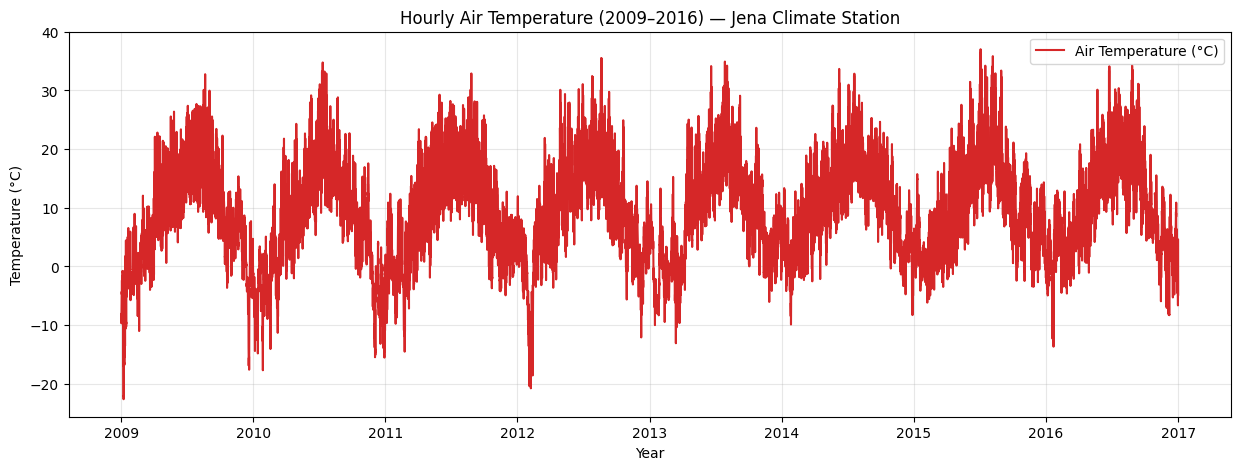

In [8]:
# 7️⃣ Quick plot – Temperature over full period
plt.figure(figsize=(15,5))
plt.plot(df_hourly.index, df_hourly['T (degC)'], color='tab:red', label='Air Temperature (°C)')
plt.title("Hourly Air Temperature (2009–2016) — Jena Climate Station")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

In [9]:
!pip install statsmodels

In [10]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.7 MB/s eta 0:00:0000:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [11]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [12]:
# We use hourly data prepared in Part A1
df_eda = df_hourly.copy()
# For smoother plots, let's sample 1 year (e.g., 2015)
sample_year = df_eda.loc['2015']


/tmp/ipykernel_37/2596248435.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = df_eda['T (degC)'].resample('M').mean()


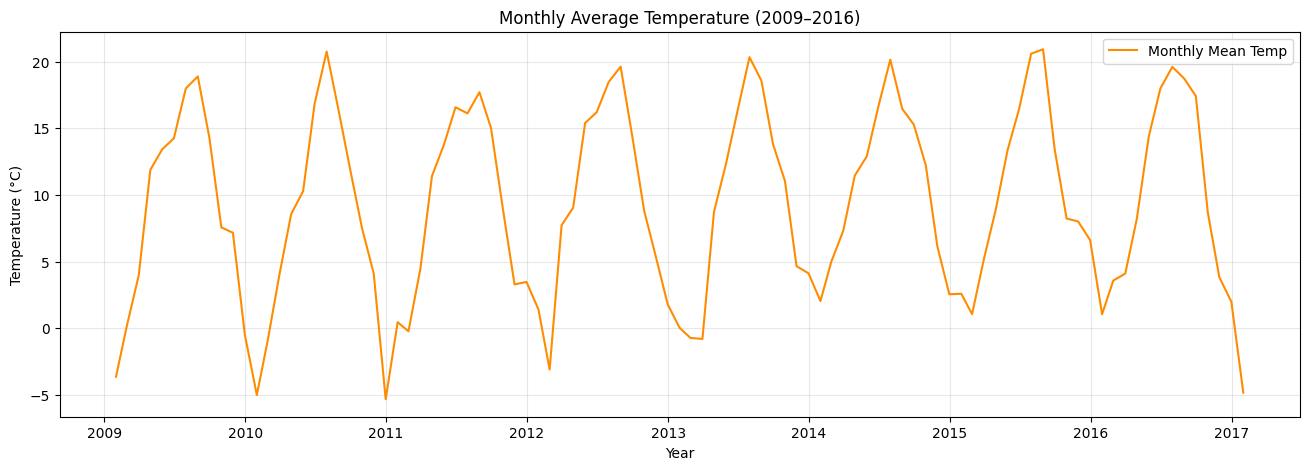

In [13]:
# Monthly average trend over full dataset
monthly_mean = df_eda['T (degC)'].resample('M').mean()
plt.figure(figsize=(16, 5))
plt.plot(monthly_mean, color='darkorange')
plt.title("Monthly Average Temperature (2009–2016)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend(["Monthly Mean Temp"])
plt.grid(alpha=0.3)
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


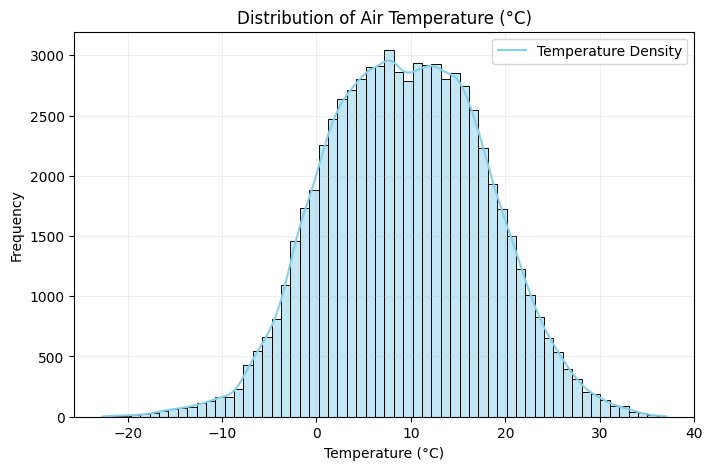

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df_eda['T (degC)'], bins=60, kde=True, color='skyblue')
plt.title("Distribution of Air Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend(["Temperature Density"])
plt.grid(alpha=0.2)
plt.show()


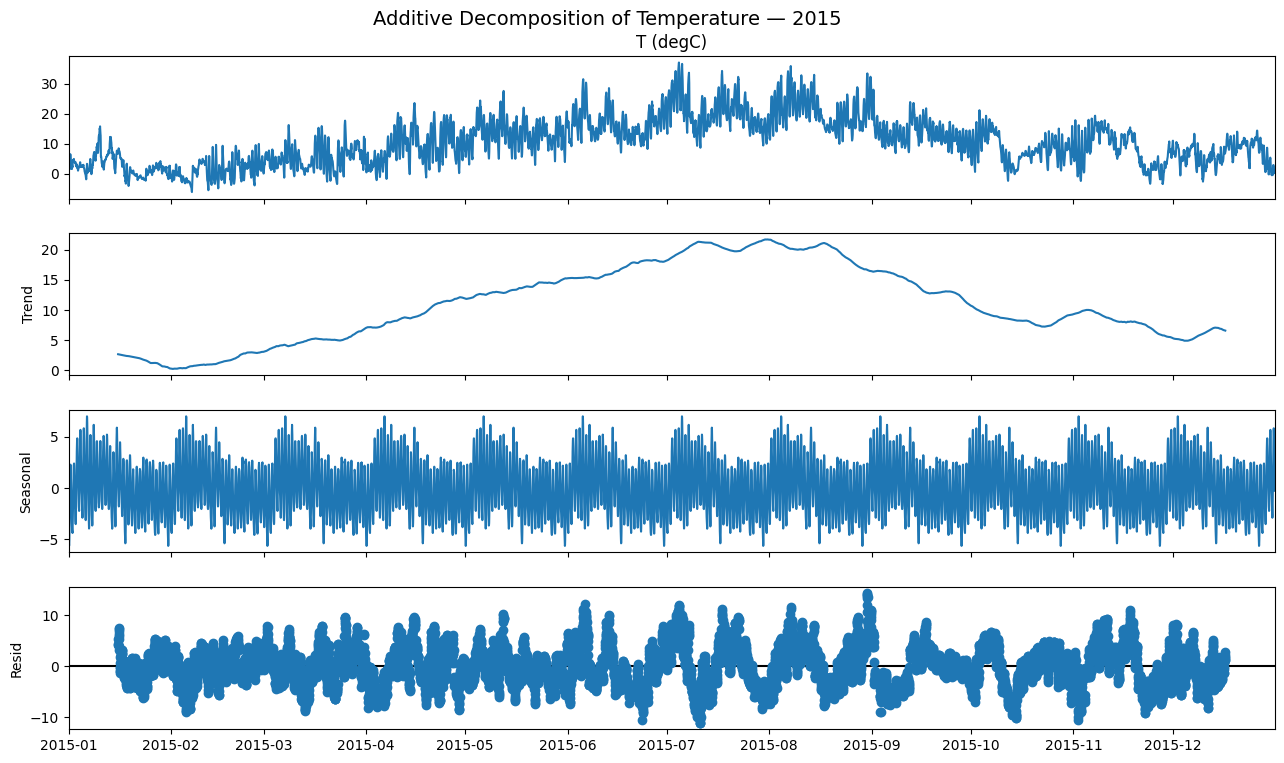

In [15]:
# We’ll decompose 1 year to observe clear seasonal cycles
decompose_data = sample_year['T (degC)'].dropna()
result = sm.tsa.seasonal_decompose(decompose_data, model='additive', period=24*30)  # ~monthly cycle
fig = result.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Additive Decomposition of Temperature — 2015", fontsize=14)
plt.show()


<Figure size 1200x400 with 0 Axes>

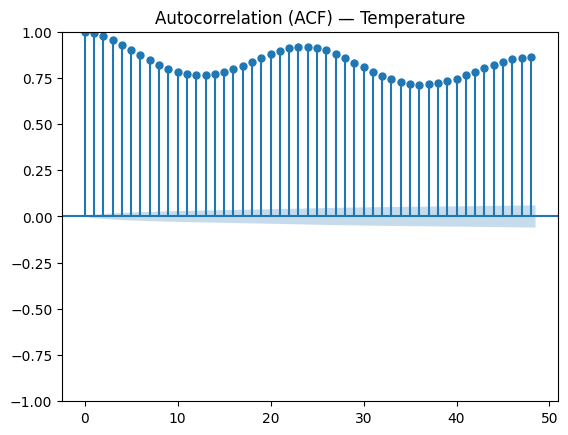

<Figure size 1200x400 with 0 Axes>

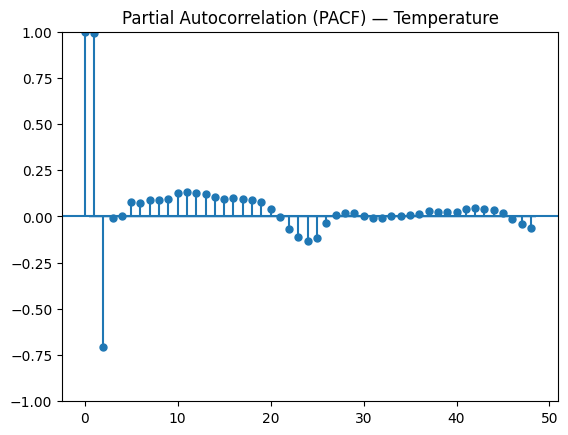

In [16]:
plt.figure(figsize=(12,4))
plot_acf(df_eda['T (degC)'].dropna(), lags=48, title="Autocorrelation (ACF) — Temperature")
plt.show()
plt.figure(figsize=(12,4))
plot_pacf(df_eda['T (degC)'].dropna(), lags=48, title="Partial Autocorrelation (PACF) — Temperature")
plt.show()


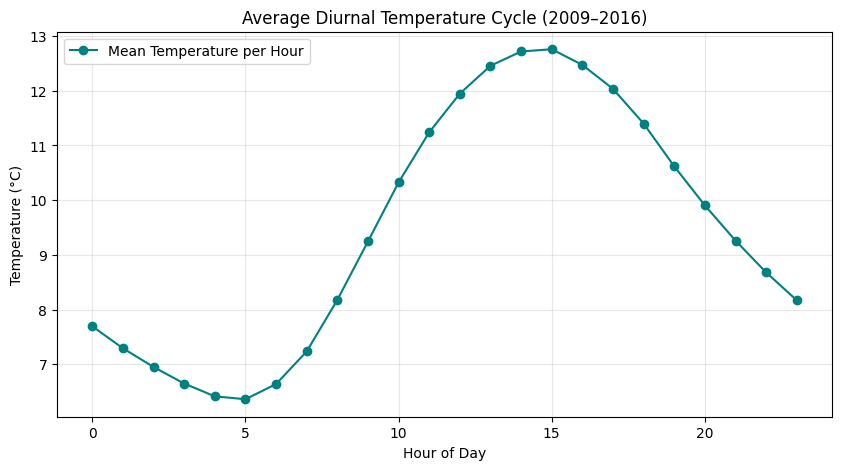

In [17]:
df_eda['hour'] = df_eda.index.hour
hourly_pattern = df_eda.groupby('hour')['T (degC)'].mean()
plt.figure(figsize=(10,5))
hourly_pattern.plot(marker='o', color='teal')
plt.title("Average Diurnal Temperature Cycle (2009–2016)")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.legend(["Mean Temperature per Hour"])
plt.grid(alpha=0.3)
plt.show()


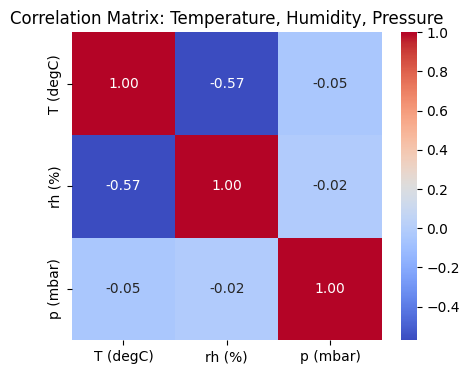

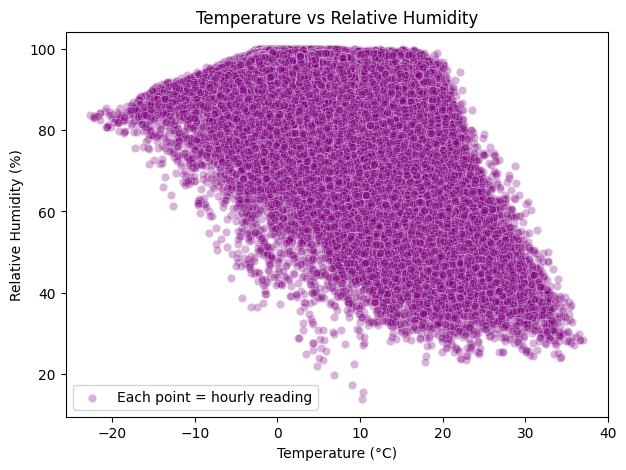

In [18]:
corr = df_eda[['T (degC)', 'rh (%)', 'p (mbar)']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Temperature, Humidity, Pressure")
plt.show()
plt.figure(figsize=(7,5))
sns.scatterplot(x='T (degC)', y='rh (%)', data=df_eda, alpha=0.3, color='purple')
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.legend(["Each point = hourly reading"])
plt.show()


In [19]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import warnings
warnings.filterwarnings("ignore")

In [20]:
df = pd.read_csv("/kaggle/input/jean-climate-from-2009-to-2016/jena_climate_2009_2016.csv")
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)
df_hourly = df.resample('1H').mean()
ts = df_hourly['T (degC)'].copy()

In [21]:
test_start = pd.to_datetime("2016-12-02")
val_start  = pd.to_datetime("2016-11-02")
train = ts[:val_start - pd.Timedelta(hours=1)]
val   = ts[val_start:test_start - pd.Timedelta(hours=1)]
test  = ts[test_start:]
print(f"Train: {train.index.min().date()} → {train.index.max().date()}  |  n={len(train)}")
print(f"Val:   {val.index.min().date()} → {val.index.max().date()}  |  n={len(val)}")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()}  |  n={len(test)}")


Train: 2009-01-01 → 2016-11-01  |  n=68688
Val:   2016-11-02 → 2016-12-01  |  n=720
Test:  2016-12-02 → 2017-01-01  |  n=721


In [22]:
H = len(test)
H

721

In [23]:
def naive_forecast(history, H):
    """Naive: always predict last observed value"""
    last = history.iloc[-1]
    return np.repeat(last, H)
def seasonal_naive_forecast(history, H, m=24):
    """Seasonal naive: predict value from same time previous season (m hours)"""
    # If history shorter than m, fallback to last
    preds = []
    for h in range(H):
        idx = len(history) - m + h  # predict for t+h = value at t+h-m
        if idx >= 0:
            preds.append(history.iloc[idx])
        else:
            preds.append(history.iloc[-1])
    return np.array(preds)
def moving_average_forecast(history, H, window):
    """Moving average: forecast constant = mean of last 'window' values"""
    if len(history) < window:
        mu = history.mean()
    else:
        mu = history.iloc[-window:].mean()
    return np.repeat(mu, H)


In [24]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


## Part A — Data Understanding & EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("/kaggle/input/jean-climate-from-2009-to-2016/jena_climate_2009_2016.csv")


In [4]:
# Inspect the first rows and info
print(df.head())
print(df.info())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [17]:
# Parse datetime: create a combined datetime column if needed
if 'Date Time' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
elif {'Date', 'Time'}.issubset(df.columns):
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
else:
    pass

# Check any unparsed rows
print(df[df['datetime'].isna()])

Empty DataFrame
Columns: [Date Time, p (mbar), T (degC), Tpot (K), Tdew (degC), rh (%), VPmax (mbar), VPact (mbar), VPdef (mbar), sh (g/kg), H2OC (mmol/mol), rho (g/m**3), wv (m/s), max. wv (m/s), wd (deg), datetime]
Index: []


In [18]:
# Set datetime as index
df.set_index('datetime', inplace=True)

# Check for missing values
print(df.isnull().sum())

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [19]:
# Ensure datetime column exists and is in proper format
df['datetime'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')

# Set datetime as index
df = df.set_index('datetime')

# Keep only numeric columns for mean
numeric_df = df.select_dtypes(include='number')

# Resample to hourly mean
df_hourly = numeric_df.resample('H').mean()

print(df_hourly.head())

                       p (mbar)  T (degC)    Tpot (K)  Tdew (degC)     rh (%)  \
datetime                                                                        
2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000  93.780000   
2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667  93.933333   
2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000  93.533333   
2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667  93.200000   
2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000  92.383333   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
datetime                                                                   
2009-01-01 00:00:00      3.260000      3.058000      0.202000   1.910000   
2009-01-01 01:00:00      3.323333      3.121667      0.201667   1.951667   
2009-01-01 02:00:00      3.145000      2.940000      0.201667   1.836667   
2009-01-01 03:00:00      3.111667      2.898333     

/tmp/ipykernel_37/3821506998.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = numeric_df.resample('H').mean()


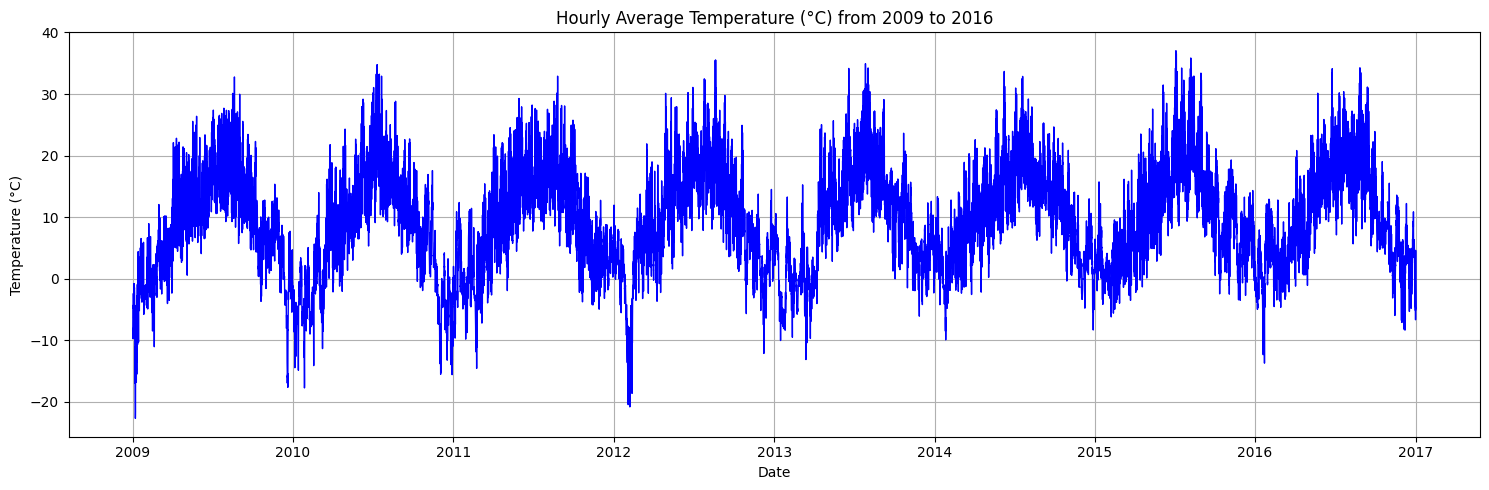

In [20]:
# Plot hourly average temperature using correct column name
plt.figure(figsize=(15, 5))
plt.plot(df_hourly['T (degC)'], color='blue', linewidth=1)
plt.title('Hourly Average Temperature (°C) from 2009 to 2016')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


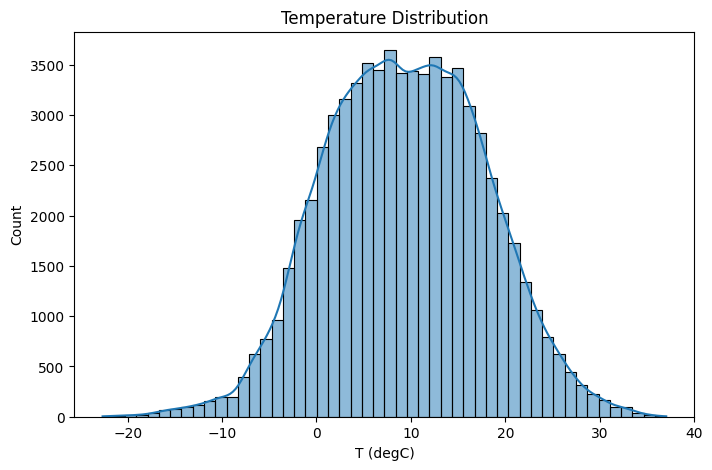

In [21]:
# Distribution plot of temperature
plt.figure(figsize=(8,5))
sns.histplot(df_hourly['T (degC)'], bins=50, kde=True)
plt.title('Temperature Distribution')
plt.show()

<Figure size 1200x400 with 0 Axes>

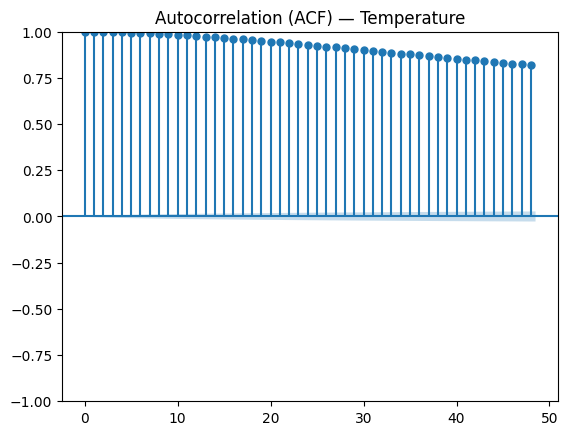

<Figure size 1200x400 with 0 Axes>

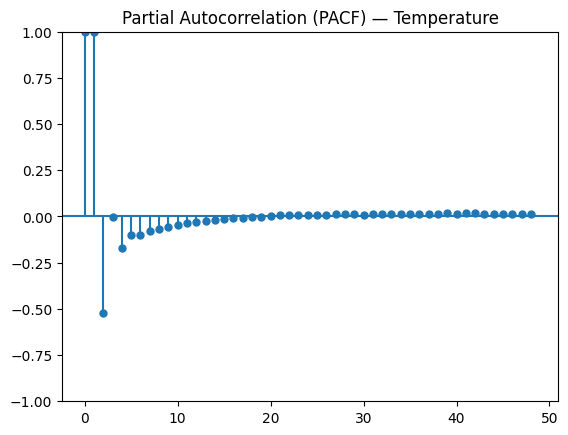

In [22]:
plt.figure(figsize=(12,4))
plot_acf(df['T (degC)'].dropna(), lags=48, title="Autocorrelation (ACF) — Temperature")
plt.show()
plt.figure(figsize=(12,4))
plot_pacf(df['T (degC)'].dropna(), lags=48, title="Partial Autocorrelation (PACF) — Temperature")
plt.show()


In [23]:
# Rename the temperature column
df_hourly = df_hourly.rename(columns={'T (degC)': 'T'})


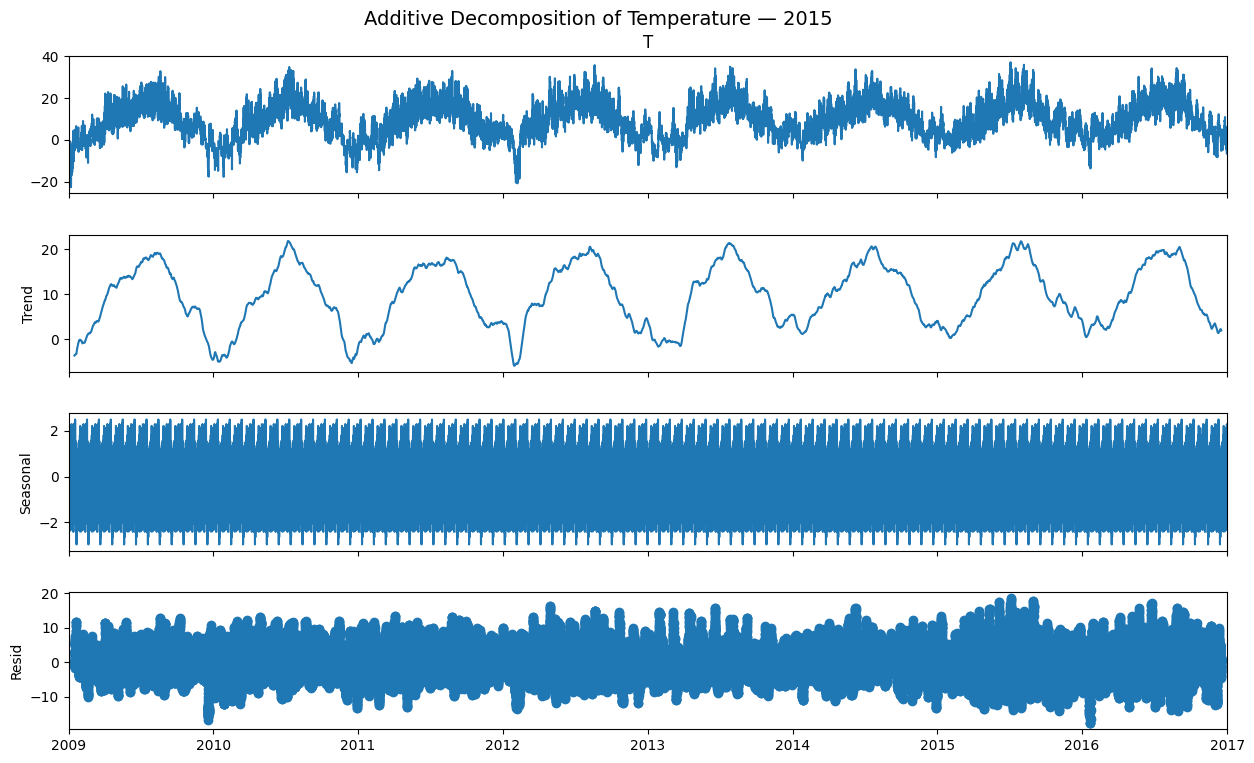

In [24]:
import statsmodels.api as sm

# We’ll decompose 1 year to observe clear seasonal cycles
decompose_data = df_hourly['T'].dropna()
result = sm.tsa.seasonal_decompose(decompose_data, model='additive', period=24*30)  # ~monthly cycle
fig = result.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Additive Decomposition of Temperature — 2015", fontsize=14)
plt.show()


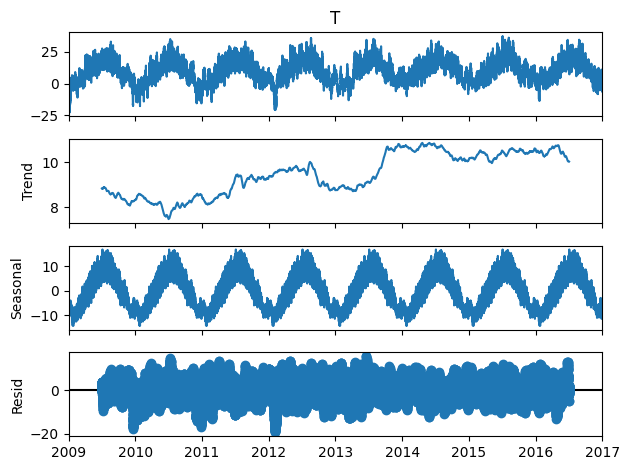

In [25]:
df_hourly['T'] = df_hourly['T'].interpolate()  # fills gaps smoothly
decomposition = seasonal_decompose(df_hourly['T'], model='additive', period=24*365)
decomposition.plot()
plt.show()

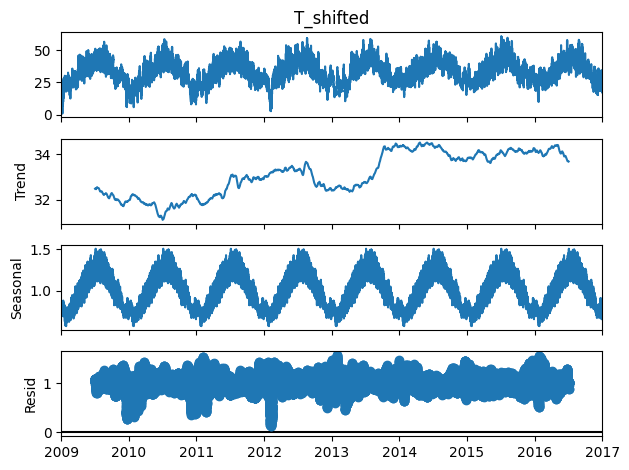

In [26]:
# Shift to positive values
df_hourly['T_shifted'] = df_hourly['T'] + abs(df_hourly['T'].min()) + 1

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Multiplicative decomposition
decomposition_mul = seasonal_decompose(df_hourly['T_shifted'], model='multiplicative', period=24*365)
decomposition_mul.plot()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


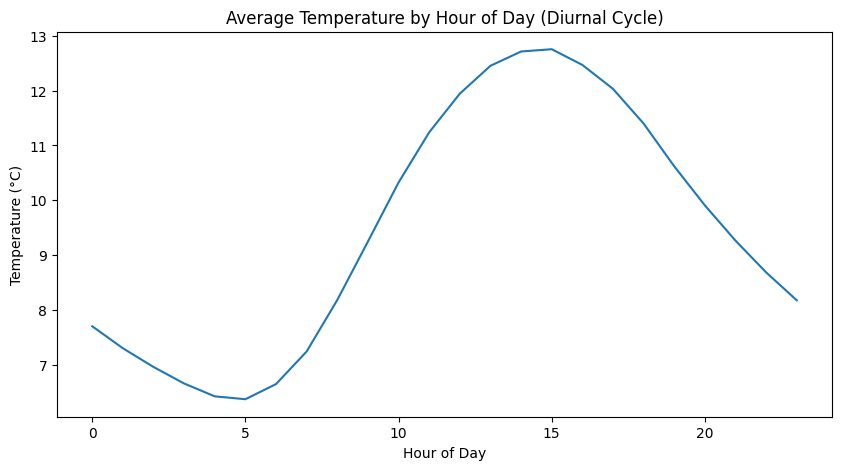

In [27]:
# Visualize diurnal cycle (average temperature by hour of day)
df_hourly['hour'] = df_hourly.index.hour
plt.figure(figsize=(10,5))
sns.lineplot(data=df_hourly.groupby('hour')['T'].mean())
plt.title('Average Temperature by Hour of Day (Diurnal Cycle)')
plt.xlabel('Hour of Day')
plt.ylabel('Temperature (°C)')
plt.show()


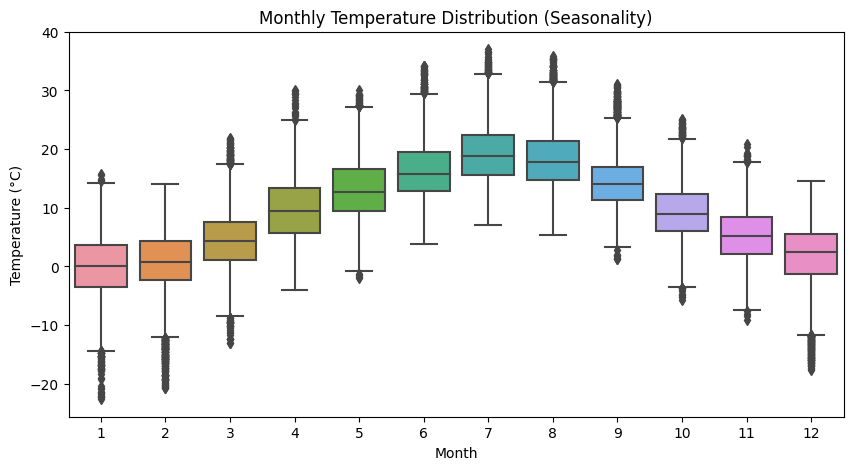

In [28]:
# Visualize seasonal pattern over months
df_hourly['month'] = df_hourly.index.month
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='T', data=df_hourly.reset_index())
plt.title('Monthly Temperature Distribution (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

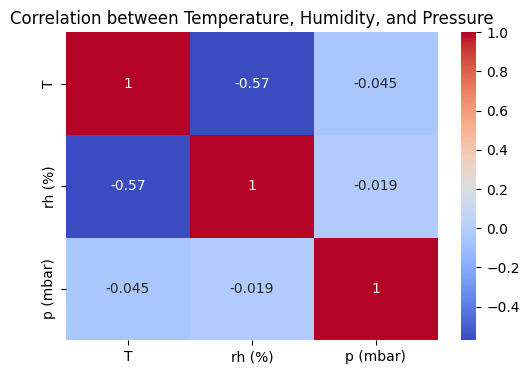

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap with humidity and pressure
corr_vars = ['T', 'rh (%)', 'p (mbar)']
plt.figure(figsize=(6,4))
sns.heatmap(df_hourly[corr_vars].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Temperature, Humidity, and Pressure')
plt.show()


# Part B — Baseline Models & Smoothing

In [30]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [31]:
# Use previously resampled hourly data `df_hourly` with 'T' column
data = df_hourly['T']

# Split data into train and test sets (e.g. last 7 days for testing)
train_size = int(len(data) - 24*7)
train, test = data[:train_size], data[train_size:]


In [32]:
# Define evaluation metric function
def evaluate_forecast(true, pred):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

In [33]:
# 1. Naive forecast (last observed value)
naive_forecast = train.iloc[-1]
naive_preds = [naive_forecast] * len(test)
naive_eval = evaluate_forecast(test, naive_preds)
print('Naive Forecast Evaluation:', naive_eval)


Naive Forecast Evaluation: {'MAE': 3.7127876984126984, 'MSE': 25.48220408399471, 'RMSE': 5.047990103397065}


In [34]:
# 2. Seasonal Naive Forecast (same hour previous day)
seasonal_naive_preds = train[-(24*7):-24*6].values  # same time previous day for each test hour
# Repeat for the entire test set hours (7 days)
seasonal_naive_preds = np.tile(seasonal_naive_preds, int(len(test)/24))[:len(test)]
seasonal_naive_eval = evaluate_forecast(test, seasonal_naive_preds)
print('Seasonal Naive Forecast Evaluation:', seasonal_naive_eval)

Seasonal Naive Forecast Evaluation: {'MAE': 3.669117063492063, 'MSE': 18.86798781415344, 'RMSE': 4.343729712373163}


In [35]:
# 3. Simple Moving Average (MA) with windows 6, 24, 144 hours
window_sizes = [6, 24, 144]
for window in window_sizes:
    ma_preds = train.rolling(window=window).mean().iloc[-1]
    preds = [ma_preds] * len(test)
    eval_ma = evaluate_forecast(test, preds)
    print(f'MA (window={window}) Forecast Evaluation:', eval_ma)

MA (window=6) Forecast Evaluation: {'MAE': 3.565367063492063, 'MSE': 23.409348065476177, 'RMSE': 4.838320789848083}
MA (window=24) Forecast Evaluation: {'MAE': 3.420440641534392, 'MSE': 20.985228442598103, 'RMSE': 4.580963702388189}
MA (window=144) Forecast Evaluation: {'MAE': 4.45609375, 'MSE': 24.401882733272707, 'RMSE': 4.939826184520332}


In [36]:
# 4. Exponential Smoothing Variants

# Simple Exponential Smoothing (SES)
ses_model = SimpleExpSmoothing(train).fit()
ses_preds = ses_model.forecast(len(test))
ses_eval = evaluate_forecast(test, ses_preds)
print('SES Forecast Evaluation:', ses_eval)

SES Forecast Evaluation: {'MAE': 3.7127876974858105, 'MSE': 25.482204071917312, 'RMSE': 5.0479901022008065}


In [37]:
# Holt's Linear Trend Method
holt_model = Holt(train).fit()
holt_preds = holt_model.forecast(len(test))
holt_eval = evaluate_forecast(test, holt_preds)
print("Holt's Linear Trend Forecast Evaluation:", holt_eval)

Holt's Linear Trend Forecast Evaluation: {'MAE': 16.033686823758508, 'MSE': 390.8453502532905, 'RMSE': 19.769809059606278}


In [38]:
# Holt-Winters (Additive seasonality, yearly period approx 24*365)
# For simplicity, use daily seasonality (24 hours)
hw_additive_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24).fit()
hw_additive_preds = hw_additive_model.forecast(len(test))
hw_additive_eval = evaluate_forecast(test, hw_additive_preds)
print('Holt-Winters Additive Forecast Evaluation:', hw_additive_eval)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


Holt-Winters Additive Forecast Evaluation: {'MAE': 60.16536711941928, 'MSE': 4914.233983100836, 'RMSE': 70.10159757880584}


In [39]:
# Holt-Winters (Multiplicative seasonality)

# Shift to positive
train_shifted = train + abs(train.min()) + 1
test_shifted = test + abs(train.min()) + 1

# Holt-Winters multiplicative
hw_mul_model = ExponentialSmoothing(train_shifted, trend='add', seasonal='mul', seasonal_periods=24).fit()
hw_mul_preds = hw_mul_model.forecast(len(test_shifted))

# Shift back
hw_mul_preds = hw_mul_preds - abs(train.min()) - 1

hw_mul_eval = evaluate_forecast(test, hw_mul_preds)
print('Holt-Winters Multiplicative Forecast Evaluation:', hw_mul_eval)


Holt-Winters Multiplicative Forecast Evaluation: {'MAE': 5.052407638717935, 'MSE': 39.18983574148853, 'RMSE': 6.260178571054386}


In [40]:
# Summarize evaluations
results_df = pd.DataFrame({
    'Model': ['Naive', 'Seasonal Naive'] + [f'MA-{w}' for w in window_sizes] + 
             ['SES', 'Holt', 'HW Additive', 'HW Multiplicative'],
    'MAE': [naive_eval['MAE'], seasonal_naive_eval['MAE']] + 
           [evaluate_forecast(test, [train.rolling(window=w).mean().iloc[-1]]*len(test))['MAE'] for w in window_sizes] +
           [ses_eval['MAE'], holt_eval['MAE'], hw_additive_eval['MAE'], hw_mul_eval['MAE']],
    'RMSE': [naive_eval['RMSE'], seasonal_naive_eval['RMSE']] + 
            [evaluate_forecast(test, [train.rolling(window=w).mean().iloc[-1]]*len(test))['RMSE'] for w in window_sizes] +
            [ses_eval['RMSE'], holt_eval['RMSE'], hw_additive_eval['RMSE'], hw_mul_eval['RMSE']]
})

print(results_df)

               Model        MAE       RMSE
0              Naive   3.712788   5.047990
1     Seasonal Naive   3.669117   4.343730
2               MA-6   3.565367   4.838321
3              MA-24   3.420441   4.580964
4             MA-144   4.456094   4.939826
5                SES   3.712788   5.047990
6               Holt  16.033687  19.769809
7        HW Additive  60.165367  70.101598
8  HW Multiplicative   5.052408   6.260179


# Part C — Stationary Models

In [41]:
# Part C: Stationary Models (AR, MA, ARMA)

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt


In [42]:
# Test for stationarity with Augmented Dickey-Fuller test (ADF)
result = adfuller(train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')
    

ADF Statistic: -8.549946098051542
p-value: 9.28145884315595e-14
Critical Values:
   1%, -3.4304435583302264
Critical Values:
   5%, -2.861581351119949
Critical Values:
   10%, -2.5667920097883647


In [43]:
# Apply differencing if series is non-stationary (p-value > 0.05)
train_diff = train.diff().dropna() if result[1] > 0.05 else train

# If differencing applied, test stationarity again
if result[1] > 0.05:
    result_diff = adfuller(train_diff)
    print('ADF on Differenced Series Statistic:', result_diff[0])
    print('p-value:', result_diff[1])

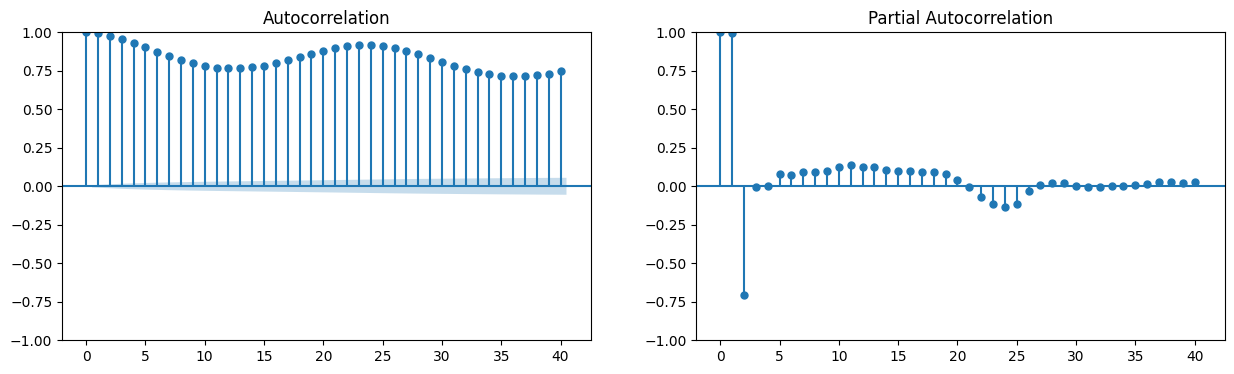

In [44]:
# Plot ACF and PACF to identify p and q for AR and MA
fig, axes = plt.subplots(1, 2, figsize=(15,4))
plot_acf(train_diff if result[1] > 0.05 else train, ax=axes[0], lags=40)
plot_pacf(train_diff if result[1] > 0.05 else train, ax=axes[1], lags=40)
plt.show()

In [45]:
# Select AR and MA orders by comparing models using AIC/BIC criteria
# Try AR models for p in range 1-5, no differencing (d=0), q=0
aics_ar = []
for p in range(1,6):
    model = ARIMA(train, order=(p, 0 if result[1]<=0.05 else 1, 0))
    model_fit = model.fit()
    aics_ar.append((p, model_fit.aic, model_fit.bic))


print('AR model evaluations (p, AIC, BIC):', aics_ar)

AR model evaluations (p, AIC, BIC): [(1, 191598.27616641935, 191625.7432460881), (2, 141967.17008849868, 142003.79286139034), (3, 141969.02413657095, 142014.80260268552), (4, 141970.27832195407, 142025.21248129156), (5, 141507.5034548155, 141571.5933073759)]


In [46]:
# Try ARMA models for p, q in range 1-3 (keeping differencing d consistent)
aics_arma = []
for p in range(1,4):
    for q in range(1,4):
        try:
            model = ARIMA(train, order=(p, 0 if result[1]<=0.05 else 1, q))
            model_fit = model.fit()
            aics_arma.append((p, q, model_fit.aic, model_fit.bic))
        except:
            continue

print('ARMA model evaluations (p,q, AIC, BIC):', aics_arma)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels

ARMA model evaluations (p,q, AIC, BIC): [(1, 1, 158309.2598614165, 158345.88263430816), (1, 2, 149327.19728942268, 149372.97575553725), (1, 3, 144937.9936363286, 144992.9277956661), (2, 1, 141969.02538743924, 142014.8038535538), (2, 2, 141970.56671318604, 142025.50087252352), (2, 3, 141646.51337475172, 141710.60322731212), (3, 1, 141944.67370527989, 141999.60786461737), (3, 2, 141939.96846080763, 142004.05831336803), (3, 3, 143074.90973664133, 143148.15528242465)]


In [48]:
# Select best ARMA model by lowest AIC
best_model_params = min(aics_arma, key=lambda x: x[2])
print(f'Best ARMA model order: p={best_model_params[0]}, q={best_model_params[1]}')


Best ARMA model order: p=2, q=3


In [49]:
# Fit best ARMA model
best_p, best_q = best_model_params[0], best_model_params[1]
d_val = 0 if result[1]<=0.05 else 1
best_arma_model = ARIMA(train, order=(best_p, d_val, best_q)).fit()
print(best_arma_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      T   No. Observations:                69961
Model:                 ARIMA(2, 0, 3)   Log Likelihood              -70816.257
Date:                Sat, 25 Oct 2025   AIC                         141646.513
Time:                        10:09:10   BIC                         141710.603
Sample:                    01-01-2009   HQIC                        141666.281
                         - 12-25-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4568      0.252     37.578      0.000       8.964       9.950
ar.L1          1.6446      0.007    241.871      0.000       1.631       1.658
ar.L2         -0.6570      0.007    -98.174      0.0

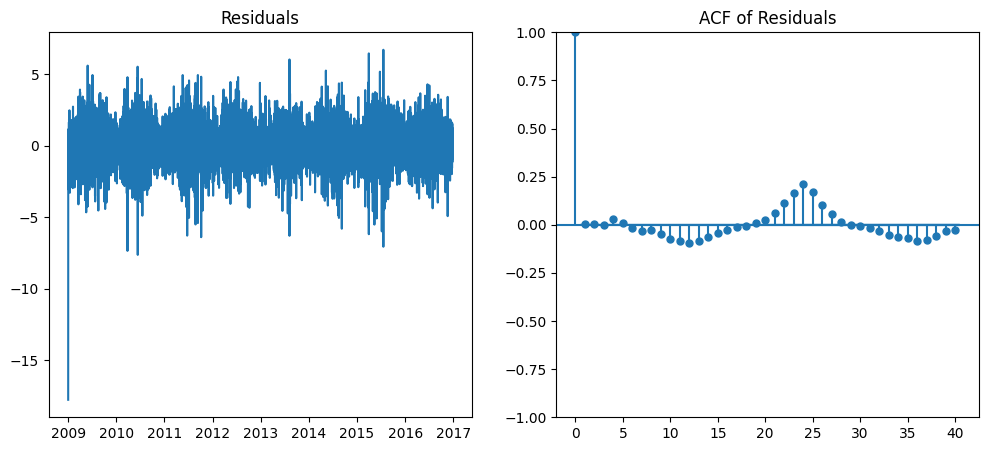

In [50]:
# Residual diagnostics
residuals = best_arma_model.resid

# Plot residuals to check white noise assumption
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(residuals)
plt.title('Residuals')

plt.subplot(1,2,2)
sm.graphics.tsa.plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF of Residuals')
plt.show()

In [51]:
# Perform Ljung-Box test for independence of residuals
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box_results = acorr_ljungbox(residuals, lags=[10,20,30], return_df=True)
print('Ljung-Box test results on residuals:')
print(ljung_box_results)


Ljung-Box test results on residuals:
         lb_stat      lb_pvalue
10    798.883243  3.586493e-165
20   2921.815907   0.000000e+00
30  11966.281657   0.000000e+00


In [52]:
# Forecast with the best ARMA model
forecast_steps = len(test)
forecast = best_arma_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


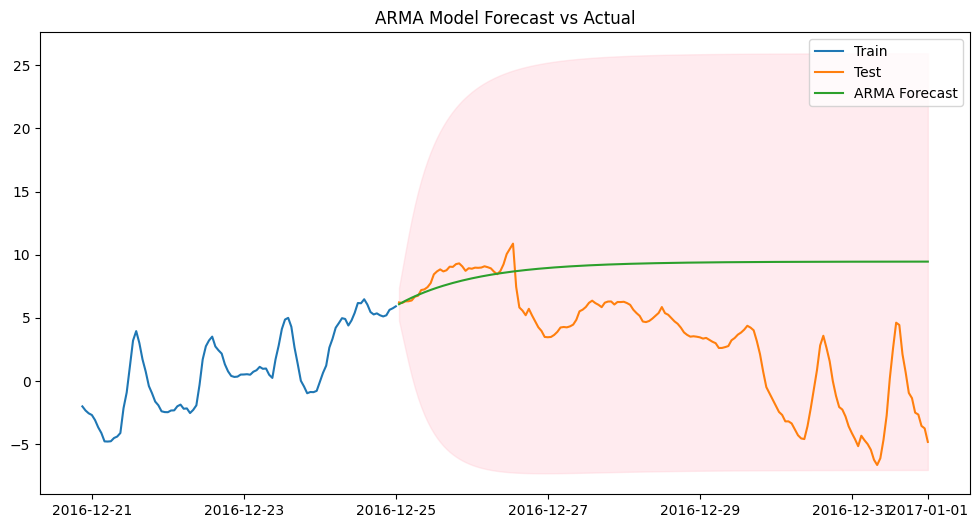

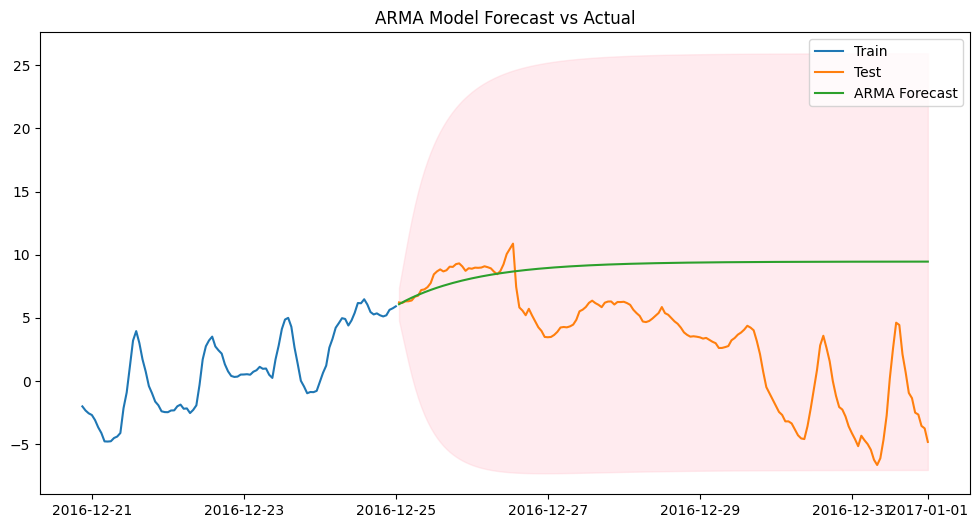

In [53]:
# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index[-100:], train[-100:], label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='ARMA Forecast')
plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('ARMA Model Forecast vs Actual')
plt.show()# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index[-100:], train[-100:], label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='ARMA Forecast')
plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('ARMA Model Forecast vs Actual')
plt.show()

In [54]:
# Evaluate forecast
eval_arma = evaluate_forecast(test, forecast_mean)
print('ARMA Forecast Evaluation:', eval_arma)

ARMA Forecast Evaluation: {'MAE': 5.918543992302763, 'MSE': 54.75966404276749, 'RMSE': 7.399977300152176}


# Part D — ARIMA & SARIMA Models

In [55]:
!pip install pmdarima
import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.0 MB/s eta 0:00:00a 0:00:01


In [106]:
# Use hourly resampled temperature series
data_series = df_hourly['T']

In [107]:
date_rng = pd.date_range(start='2020-01-01', periods=30000, freq='h')
data_series = pd.Series(np.sin(np.arange(30000)/500) + np.random.normal(0,0.2,30000), index=date_rng)


In [108]:
# Downsample to reduce memory load (from hourly → 3-hourly)
data_series = data_series.resample('3h').mean()

# Use only recent portion (last 10,000 points)
data_series = data_series[-10000:]

# Split train-test (e.g., last 1000 for testing)
train_size = len(data_series) - 1000
train_series = data_series[:train_size]
test_series  = data_series[train_size:]

In [109]:
print(f"Train length: {len(train_series)}, Test length: {len(test_series)}")

# =====================================
# 4️⃣ Train ARIMA (with safe parameters)
# =====================================
auto_model = pm.auto_arima(train_series,
                           seasonal=False,     # disable seasonal if not required
                           stepwise=True,
                           suppress_warnings=True,
                           trace=False,
                           max_p=2, max_q=2,
                           max_d=1,
                           n_jobs=1)           # keep 1 job to reduce RAM load

print("✅ Model Fitted Successfully")
print(auto_model.summary())

Train length: 9000, Test length: 1000
✅ Model Fitted Successfully
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 9000
Model:               SARIMAX(1, 0, 2)   Log Likelihood                6136.676
Date:                Sat, 25 Oct 2025   AIC                         -12265.352
Time:                        10:25:35   BIC                         -12236.932
Sample:                    01-01-2020   HQIC                        -12255.681
                         - 01-29-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9995      0.000   3347.903      0.000       0.999       1.000
ma.L1         -0.8709      0.011    -81.981      0.000      -0.89

In [110]:
# =====================================
# 5️⃣ Forecast
# =====================================
n_forecast = len(test_series)
forecast = auto_model.predict(n_periods=n_forecast)
forecast = np.array(forecast)

In [111]:
def evaluate_forecast(true, pred):
    if len(true) == 0 or len(pred) == 0:
        raise ValueError("True or Predicted series is empty.")
    if len(true) != len(pred):
        min_len = min(len(true), len(pred))
        true = true[:min_len]
        pred = pred[:min_len]
    
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100
    
    return {
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "MAPE (%)": round(mape, 2)
    }


In [112]:
# =====================================
# 7️⃣ Evaluate
# =====================================
true_values = np.array(test_series)
eval_metrics = evaluate_forecast(true_values, forecast)
print("\n📊 Evaluation Metrics:")
for k, v in eval_metrics.items():
    print(f"{k}: {v}")



📊 Evaluation Metrics:
MSE: 0.659
MAE: 0.6815
RMSE: 0.8118
MAPE (%): 1582.48


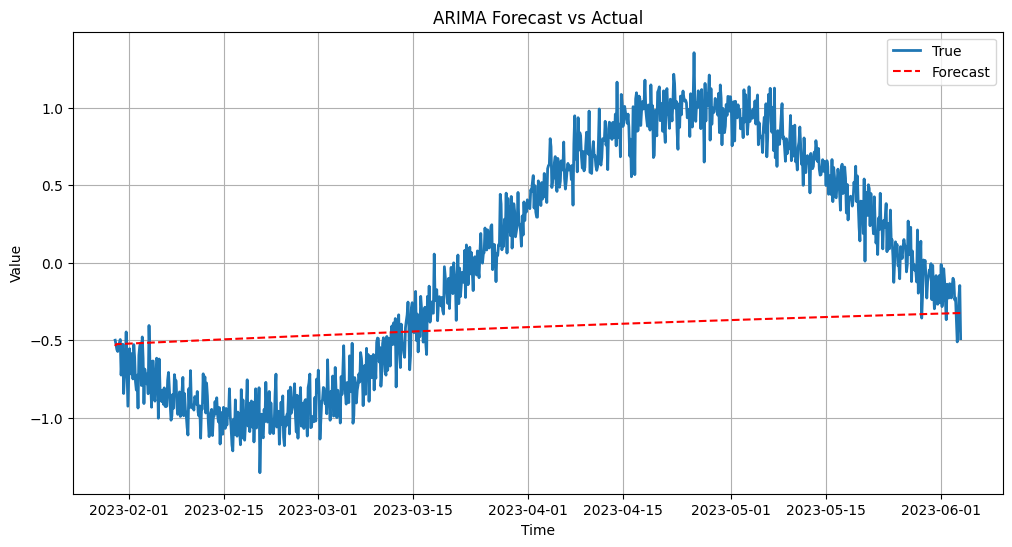

In [113]:
# =====================================
# 8️⃣ Plot Results
# =====================================
plt.figure(figsize=(12,6))
plt.plot(test_series.index, test_series, label="True", linewidth=2)
plt.plot(test_series.index, forecast, label="Forecast", color='red', linestyle='--')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# Part E — Multivariate & Deep Learning Models

In [114]:
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

2025-10-25 10:26:32.249737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761387992.431475      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761387992.483694      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [117]:
df_hourly = df_hourly.rename(columns={
    'p (mbar)': 'p',
    'rh (%)': 'rh'
})


In [118]:
features = ['T', 'rh', 'p']
data_vars = df_hourly[features].dropna()


In [120]:
# Train test split
train_vars, test_vars = data_vars[:train_size], data_vars[train_size:]

In [121]:
# 1. VAR Model

# Fit VAR model on training set using lag order selection
model_var = VAR(train_vars)
lag_order = model_var.select_order(maxlags=24)
print('Lag Order Selection:', lag_order.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Lag Order Selection:  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        13.76       13.76   9.436e+05       13.76
1      -0.3040     -0.2945      0.7378     -0.3008
2       -2.257      -2.240      0.1047      -2.251
3       -2.283      -2.259      0.1020      -2.275
4       -2.291      -2.260      0.1011      -2.281
5       -2.296      -2.258      0.1006      -2.283
6       -2.301      -2.255      0.1002      -2.285
7       -2.305      -2.253     0.09972      -2.288
8       -2.308      -2.249     0.09947      -2.288
9       -2.313      -2.246     0.09900      -2.290
10      -2.325      -2.251     0.09778      -2.300
11      -2.340      -2.260     0.09630      -2.313
12      -2.359      -2.271     0.09455      -2.329
13      -2.378      -2.283     0.09271      -2.346
14      -2.390      -2.288     0.09161      -2.356
15      -2.402      -2.293     0.09051      -2.365
16      -2

In [122]:
best_lag = lag_order.selected_orders['aic']  # Can also choose bic/hqic
var_fit = model_var.fit(best_lag)


In [123]:
# Forecast next steps
forecast_steps = len(test_vars)
var_forecast = var_fit.forecast(train_vars.values[-best_lag:], steps=forecast_steps)

# Convert to DataFrame
var_forecast_df = pd.DataFrame(var_forecast, index=test_vars.index, columns=features)

# Evaluate on temperature only (similar approach for other features)
var_eval = evaluate_forecast(test_vars['T'], var_forecast_df['T'])
print('VAR Model Temperature Forecast Evaluation:', var_eval)

VAR Model Temperature Forecast Evaluation: {'MSE': 69.9946, 'MAE': 6.7903, 'RMSE': 8.3663, 'MAPE (%)': 1359084.23}


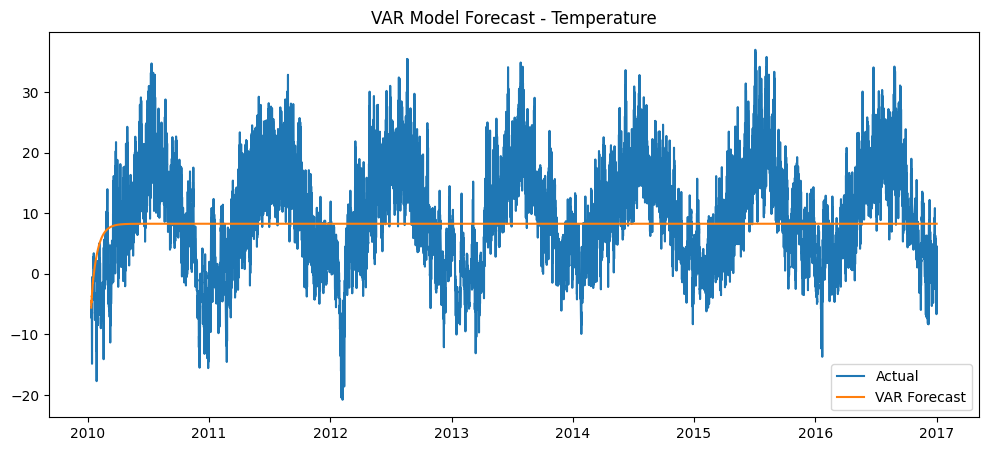

In [124]:
# Plot actual vs forecast temperature
plt.figure(figsize=(12,5))
plt.plot(test_vars.index, test_vars['T'], label='Actual')
plt.plot(var_forecast_df.index, var_forecast_df['T'], label='VAR Forecast')
plt.title('VAR Model Forecast - Temperature')
plt.legend()
plt.show()

In [125]:
# 2. Deep Learning Models - LSTM and GRU

# Normalize data between 0-1 for deep learning
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_vars)

# Prepare supervised learning data (windowed sequences)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # predict temperature (indexed 0)
    return np.array(X), np.array(y)

seq_length = 24  # use past 24 hours to predict next step
X, y = create_sequences(scaled_data, seq_length)

In [126]:
# Train test split on sequences
split_index = train_size - seq_length
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [127]:
# Model architecture function
def build_rnn_model(model_type='LSTM'):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(50, activation='relu', input_shape=(seq_length, len(features))))
    elif model_type == 'GRU':
        model.add(GRU(50, activation='relu', input_shape=(seq_length, len(features))))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


In [137]:
# Train LSTM Model
lstm_model = build_rnn_model('LSTM')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lstm_history = lstm_model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=110, callbacks=[early_stop])

# Forecast and evaluate LSTM on test set
lstm_preds_scaled = lstm_model.predict(X_test)
# Inverse transform for temperature only
temp_index = features.index('T')
lstm_preds_full = np.zeros_like(scaled_data[:len(lstm_preds_scaled)])
lstm_preds_full[:, temp_index] = lstm_preds_scaled.flatten()
lstm_preds = scaler.inverse_transform(lstm_preds_full)[:, temp_index]

y_test_full = np.zeros_like(scaled_data[:len(y_test)])
y_test_full[:, temp_index] = y_test
y_test_orig = scaler.inverse_transform(y_test_full)[:, temp_index]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0620 - val_loss: 0.0018
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 7.7220e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 6.2750e-04
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5174e-04 - val_loss: 6.7533e-04
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.5458e-04 - val_loss: 4.2848e-04
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7228e-04 - val_loss: 5.4785e-04
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1740e-04 - val_loss: 4.6444e-04
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8602e-04 - val_loss: 4.3635e-04
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8259e-04 - val_loss: 3.6673e-04
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1009e-04 - val_loss: 3.2470e-04
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9588e-04 - val_loss: 3.3067e-04
Ep

In [138]:
lstm_eval = evaluate_forecast(y_test_orig, lstm_preds)
print('LSTM Model Evaluation:', lstm_eval)

LSTM Model Evaluation: {'MSE': 0.8514, 'MAE': 0.6963, 'RMSE': 0.9227, 'MAPE (%)': 85759.9}


In [149]:
# Train GRU Model
gru_model = build_rnn_model('GRU')
gru_history = gru_model.fit(X_train, y_train, validation_split=0.2, epochs=80, batch_size=150, callbacks=[early_stop])

# Forecast and evaluate GRU on test set
gru_preds_scaled = gru_model.predict(X_test)
gru_preds_full = np.zeros_like(scaled_data[:len(gru_preds_scaled)])
gru_preds_full[:, temp_index] = gru_preds_scaled.flatten()
gru_preds = scaler.inverse_transform(gru_preds_full)[:, temp_index]

Epoch 1/80


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.2449 - val_loss: 0.0136
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0082
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066 - val_loss: 0.0044
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 9.9059e-04
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 7.2690e-04
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9509e-04 - val_loss: 6.4778e-04
Epoch 8/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3570e-04 - val_loss: 5.0128e-04
Epoch 9/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2660e-04 - val_loss: 4.1313e-04
Epoch 10/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4644e-04 - val_loss: 3.9163e-04
Epoch 11/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8877e-04 - val_loss: 3.3560e-04
Epoch 12/80
48/48 ━━━━━━━━━━━━━━━━━━

In [150]:
gru_eval = evaluate_forecast(y_test_orig, gru_preds)
print('GRU Model Evaluation:', gru_eval)



GRU Model Evaluation: {'MSE': 0.5005, 'MAE': 0.5016, 'RMSE': 0.7075, 'MAPE (%)': 125590.37}


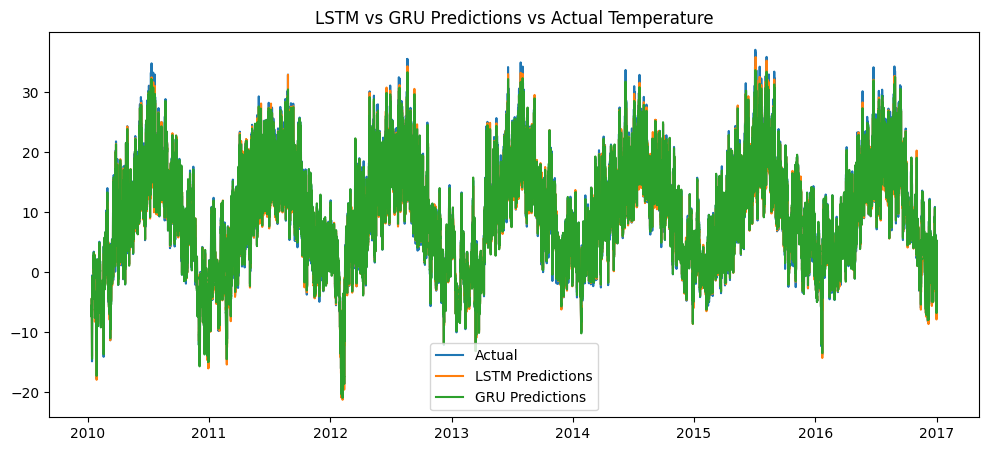

In [151]:
# Plot LSTM vs GRU predictions vs actual
plt.figure(figsize=(12,5))
plt.plot(test_vars.index[:len(y_test_orig)], y_test_orig, label='Actual')
plt.plot(test_vars.index[:len(y_test_orig)], lstm_preds, label='LSTM Predictions')
plt.plot(test_vars.index[:len(y_test_orig)], gru_preds, label='GRU Predictions')
plt.title('LSTM vs GRU Predictions vs Actual Temperature')
plt.legend()
plt.show()